### Name: Shubham Sharma

#### Github Link:- https://github.com/SHUBHAM01S2/Face-Emotion-Detection

## About Dataset
- The data consists of 48x48 pixel grayscale images of faces. The faces have been automatically registered so that the face is more or less centred and occupies about the same amount of space in each image.

- The task is to categorize each face based on the emotion shown in the facial expression into one of seven categories (Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral). The training set consists of 28,709 examples and the validation set consists of 7178 examples.


In [13]:
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [14]:
warnings.filterwarnings("ignore")

In [15]:
# Setting the dimensions and batch size for Image
img_width, img_height = 48, 48
batch_size = 64
input_shape = (img_width, img_height, 1)

In [16]:
input_shape

(48, 48, 1)

In [17]:
# Initializing the path from where the data is loading
train_dir = 'train'
test_dir = 'validation'

In [18]:
# Data Preprocessing + Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Flow from directory
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [19]:
print(train_generator.dtype)

float32


**No Need to Convert to Pixel Values:**
If your image is already in float32 format (especially with values normalized to 0-1), there's no need to convert it again to pixel values like 0-255.

**Understanding Image Data in float32:**
Pixel Values: Image data typically comes in integer form (like uint8 for 0-255 pixel values). However, when processed for machine learning or deep learning tasks, the pixel values are often normalized to a float32 range, such as 0.0 to 1.0 by dividing by 255.

For example, a pixel value of 255 in uint8 becomes 1.0 in float32.

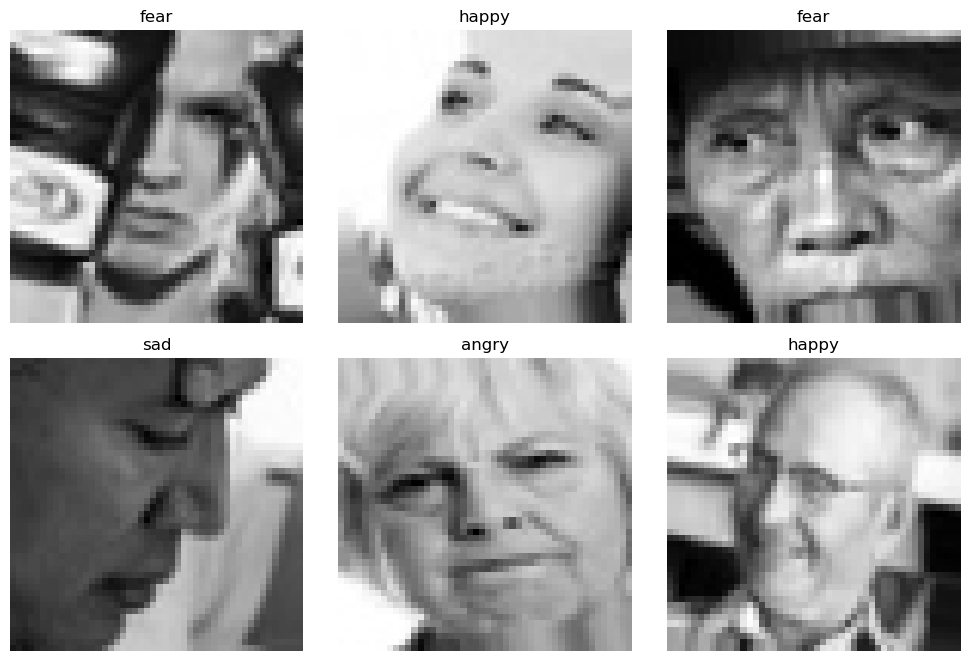

In [20]:
class_names = list(train_generator.class_indices.keys())
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(6):
    plt.subplot(3,3,i+1)

    img = images[i]  # Extract single image
    if img.shape[-1] == 1:  # Grayscale image
        plt.imshow(img.squeeze(), cmap="gray")
    else:  # RGB image
        plt.imshow(img)

    plt.title(class_names[np.argmax(labels[i])])  # Get class label
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Model Architecture

In [21]:
model = Sequential()

In [22]:
model.add(Conv2D(64, (3, 3), activation='relu', input_shape=input_shape))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7, activation='softmax'))  # 7 categories

In [23]:
# Model Compilation
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,472,711 (9.43 MB)

 Trainable params: 2,471,815 (9.43 MB)

 Non-trainable params: 896 (3.50 KB)

1. First Convolutional Layer (conv2d)

- Type: Conv2D (2D Convolution)

- Output Shape: Depends on input_shape, typically (None, H-2, W-2, 64)

- Parameters: 640

- Explanation: Applies 64 filters of size 3x3 with ReLU activation. Detects low-level features such as edges and textures.

2. Batch Normalization Layer (batch_normalization)

- Type: BatchNormalization

- Output Shape: Same as input, e.g., (None, H-2, W-2, 64)

- Parameters: 256

- Explanation: Normalizes the activations to stabilize and accelerate training.

3. First Max Pooling Layer (max_pooling2d)

- Type: MaxPooling2D

- Output Shape: Half the height and width, e.g., (None, H/2, W/2, 64)

- Parameters: 0

- Explanation: Downsamples the spatial dimensions to reduce computational load and retain prominent features.

4. First Dropout Layer (dropout)

- Type: Dropout

- Output Shape: Same as previous

- Parameters: 0

- Explanation: Randomly sets 25% of input units to zero during training to reduce overfitting.

5. Second Convolutional Layer (conv2d_1)

- Type: Conv2D

- Output Shape: Smaller spatial dims, more filters (None, H-4, W-4, 128)

- Parameters: 73856

- Explanation: Applies 128 filters of size 3x3 to learn more abstract patterns from previous features.

6. Batch Normalization Layer (batch_normalization_1)

- Type: BatchNormalization

- Output Shape: Same

- Parameters: 512

- Explanation: Normalizes activations to improve stability and training performance.

7. Second Max Pooling Layer (max_pooling2d_1)

- Type: MaxPooling2D

- Output Shape: Reduced spatial dimensions

- Parameters: 0

- Explanation: Reduces dimensionality to avoid overfitting and to highlight dominant patterns.

8. Second Dropout Layer (dropout_1)

- Type: Dropout

- Output Shape: Same

- Parameters: 0

- Explanation: Applies a 25% dropout rate for regularization.

9. Third Convolutional Layer (conv2d_2)

- Type: Conv2D

- Output Shape: Further reduced spatial size, deeper filters

- Parameters: 295168

- Explanation: Applies 256 filters for learning high-level abstract features.

10. Batch Normalization Layer (batch_normalization_2)

- Type: BatchNormalization

- Output Shape: Same

- Parameters: 1024

- Explanation: Normalizes the output of the previous layer.

11. Third Max Pooling Layer (max_pooling2d_2)

- Type: MaxPooling2D

- Output Shape: Further reduced spatial dimensions

- Parameters: 0

- Explanation: Helps in reducing computation and capturing essential features.

12. Third Dropout Layer (dropout_2)

- Type: Dropout

- Output Shape: Same

- Parameters: 0

- Explanation: Applies 25% dropout rate to reduce overfitting.

13. Flatten Layer (flatten)

- Type: Flatten

- Output Shape: (None, N) where N depends on the final pooled output

- Parameters: 0

- Explanation: Converts multi-dimensional tensor into a 1D vector to be used in dense layers.

14. Fully Connected Layer (dense)

- Type: Dense

- Output Shape: (None, 512)

- Parameters: Depends on flattened size, approximately 512×N

- Explanation: A fully connected layer with 512 neurons for final classification reasoning.

15. Dropout Layer (dropout_3)

- Type: Dropout

- Output Shape: (None, 512)

- Parameters: 0

- Explanation: Applies 50% dropout to aggressively regularize the model before the final prediction.

16. Output Layer (dense_1)

- Type: Dense

- Output Shape: (None, 7)

- Parameters: 3591

- Explanation: Final classification layer with 7 units (for 7 emotion classes). Softmax activation outputs a probability distribution across the categories.

In [25]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

In [26]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

In [ ]:
# Model Training
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=test_generator,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/40


In [ ]:
# Save the entire model to a file
model.save('emotion_recognition_model.h5')

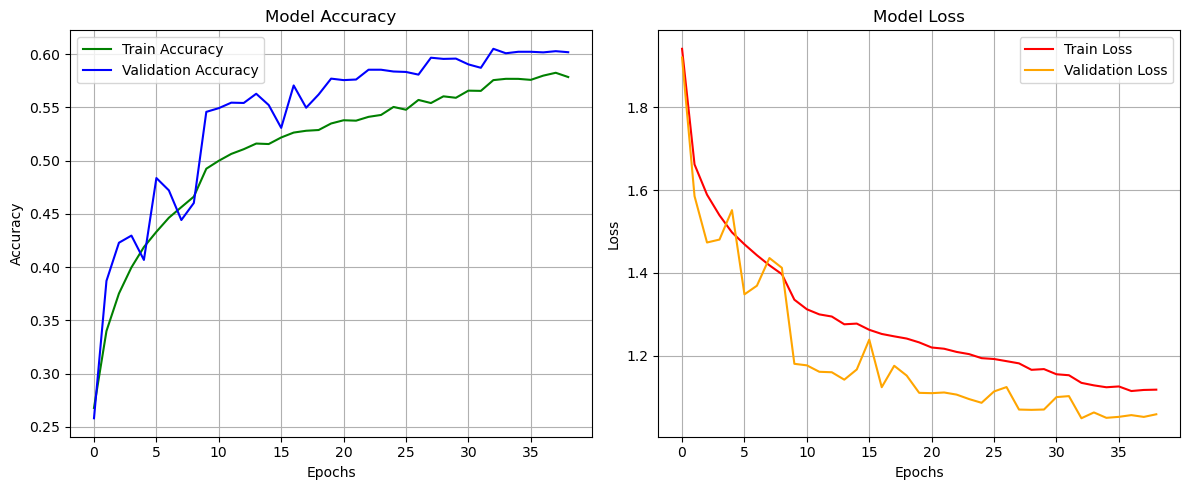

In [ ]:
# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Load your trained model
model = load_model('emotion_recognition_model.h5')

2025-04-19 17:34:52.488400: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [ ]:
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step


In [ ]:
y_true = test_generator.classes

In [ ]:
class_labels = list(test_generator.class_indices.keys())
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

Classification Report:

              precision    recall  f1-score   support

       angry       0.49      0.57      0.52       958
     disgust       0.71      0.11      0.19       111
        fear       0.46      0.21      0.29      1024
       happy       0.81      0.86      0.84      1774
     neutral       0.51      0.67      0.58      1233
         sad       0.50      0.46      0.48      1247
    surprise       0.71      0.76      0.73       831

    accuracy                           0.61      7178
   macro avg       0.60      0.52      0.52      7178
weighted avg       0.60      0.61      0.59      7178



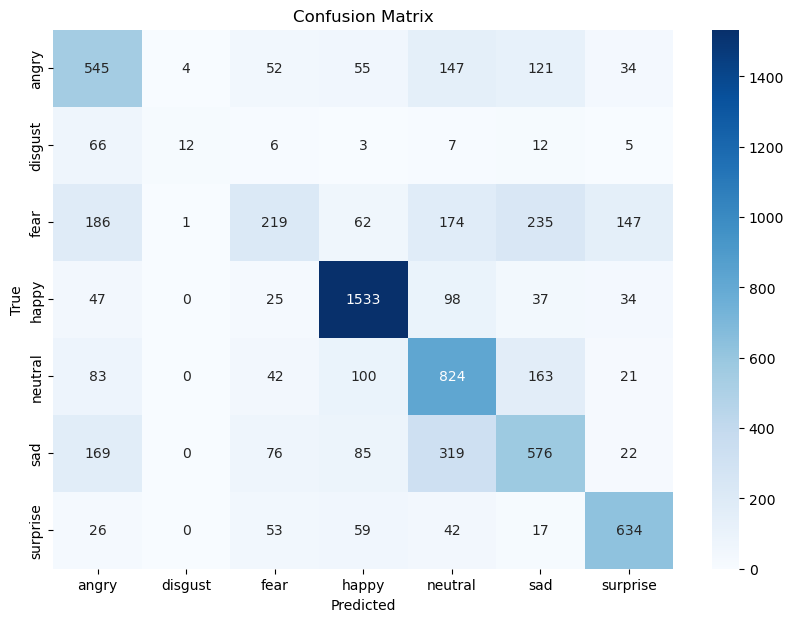

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Emotion label map (must match training order)
class_names = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

In [ ]:
# Path to test images
test_folder = 'validation'

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import random

In [ ]:
# Function to preprocess and predict single image
def predict_single_image(img_path):
    img = load_img(img_path, color_mode='grayscale', target_size=(48, 48))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_label = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    return img, predicted_label, confidence

In [ ]:
# Collect 1 random image from each class
sample_images = []
true_labels = []

for label in class_names:
    class_path = os.path.join(test_folder, label)
    file_list = os.listdir(class_path)
    if file_list:
        img_path = os.path.join(class_path, random.choice(file_list))  # pick random image
        sample_images.append(img_path)
        true_labels.append(label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


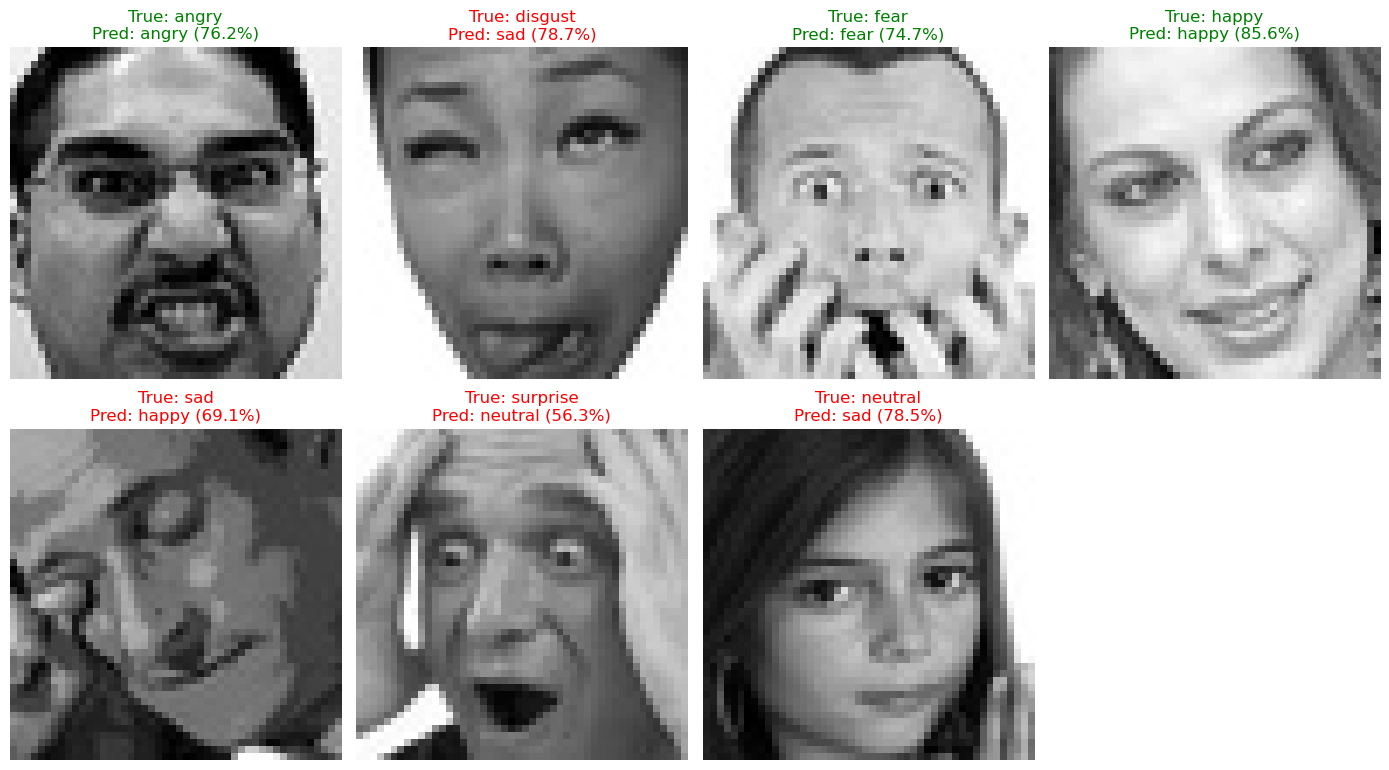

In [ ]:
# Plot and predict for each image
plt.figure(figsize=(14, 8))
for i, img_path in enumerate(sample_images):
    img, predicted_label, confidence = predict_single_image(img_path)

    plt.subplot(2, 4, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(
        f"True: {true_labels[i]}\nPred: {predicted_label} ({confidence:.1f}%)",
        color='green' if predicted_label == true_labels[i] else 'red'
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

## CNN Emotion Recognition Result Summary
- The image shows 8 sample test results from a facial emotion recognition model. Each image includes the true label and the model’s prediction with the associated confidence percentage.
---
✅ Correct Predictions (3 out of 7):
1. Angry – Correct (Confidence: 76.2%)
2. Fear – Correct (Confidence: 74.7%)
3. Happy – Correct (Confidence: 85.6%)
4. Disgust → Predicted as Sad (Confidence: 78.7%)
5. Sad → Predicted as Happy (Confidence: 69.1%)
6. Surprise → Predicted as Neutral (Confidence: 56.3%)
7. Neutral → Predicted as Sad (Confidence: 78.5%)

### Observations:
- High confidence misclassifications suggest confusion between similar facial expressions (e.g., disgust vs. sad, surprise vs. neutral).

- Happy and Fear are detected well, with confidence above 70%.

- Disgust and Neutral seem to be the most commonly misclassified emotions, indicating the need for more training samples or better feature extraction for those emotions.